# Desafío - Modelos de ensamble (Parte III)

El objetivo es construir dos modelos para clasificar si una muestra corresponde a:

- `0`: Blood Donor
- `1`: posible enfermedad en sangre / caso no Blood Donor

Modelos utilizados:

1. Regresión logística con validación cruzada y regularización **Elastic Net**.
2. **Extreme Gradient Boosting** con búsqueda de hiperparámetros y regularización L1/L2.

## 1. Importación de librerías

In [2]:
pip install xgboost


   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ------ --------------------------------- 11.8/69.5 MB 67.2 MB/s eta 0:00:01
   ------------- -------------------------- 22.8/69.5 MB 59.1 MB/s eta 0:00:01
   ------------------ --------------------- 32.5/69.5 MB 60.1 MB/s eta 0:00:01
   -------------------------- ------------- 46.1/69.5 MB 58.9 MB/s eta 0:00:01
   ------------------------------- -------- 54.5/69.5 MB 54.4 MB/s eta 0:00:01
   ----------------------------------- ---- 61.9/69.5 MB 51.3 MB/s eta 0:00:01
   ---------------------------------------- 69.5/69.5 MB 50.4 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError("Debes instalar xgboost antes de ejecutar este notebook: pip install xgboost")

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

## 2. Carga de datos

El archivo esperado es `hcvdat0.csv`. Si no está en la carpeta, el notebook intenta extraerlo desde el archivo de apoyo `Apoyo Desafío - Modelos de ensamble (Parte III).zip`.

In [4]:
csv_file = "hcvdat0.csv"
zip_file = "Apoyo Desafío - Modelos de ensamble (Parte III).zip"

if not os.path.exists(csv_file):
    if os.path.exists(zip_file):
        with zipfile.ZipFile(zip_file, "r") as zip_ref:
            zip_ref.extractall(".")
    else:
        raise FileNotFoundError("No se encontró hcvdat0.csv ni el archivo zip de apoyo.")

df = pd.read_csv(csv_file)
df.head()

,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [5]:
df.shape

(615, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,615.0,NaN,NaN,NaN,308.0,177.679487,1.0,154.5,308.0,461.5,615.0
Category,615,5,0=Blood Donor,533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,615.0,NaN,NaN,NaN,47.40813,10.055105,19.0,39.0,47.0,54.0,77.0
Sex,615,2,m,377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ALB,614.0,NaN,NaN,NaN,41.620195,5.780629,14.9,38.8,41.95,45.2,82.2
ALP,597.0,NaN,NaN,NaN,68.28392,26.028315,11.3,52.5,66.2,80.1,416.6
ALT,614.0,NaN,NaN,NaN,28.450814,25.469689,0.9,16.4,23.0,33.075,325.3
AST,615.0,NaN,NaN,NaN,34.786341,33.09069,10.6,21.6,25.9,32.9,324.0
BIL,615.0,NaN,NaN,NaN,11.396748,19.67315,0.8,5.3,7.3,11.2,254.0
CHE,615.0,NaN,NaN,NaN,8.196634,2.205657,1.42,6.935,8.26,9.59,16.41


## 3. Preparación de variables

Según el enunciado, se deben realizar estos cambios:

1. Eliminar `Unnamed: 0`.
2. Crear `target`, donde:
   - `0`: `0=Blood Donor`
   - `1`: cualquier otra categoría.
3. Crear `suspect`, donde:
   - `1`: `0s=suspect Blood Donor`
   - `0`: cualquier otro caso.
4. Eliminar `Category`.

In [8]:
df = df.drop(columns=["Unnamed: 0"])

df["target"] = np.where(df["Category"] == "0=Blood Donor", 0, 1) #condicion 1
df["suspect"] = np.where(df["Category"] == "0s=suspect Blood Donor", 1, 0) #condicion 2

df = df.drop(columns=["Category"])
df.head()

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,target,suspect
0,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0,0
1,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0,0
2,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0,0
3,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0,0
4,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0,0


Distribución de target:
target
0    533
1     82
Name: count, dtype: int64


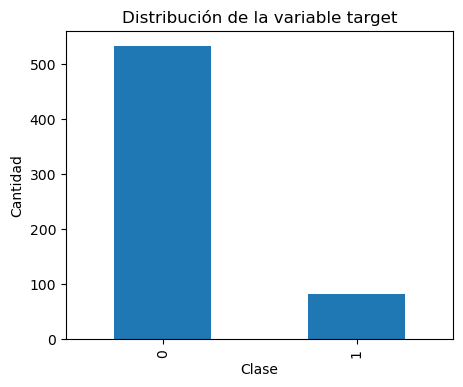

In [9]:
print("Distribución de target:")
print(df["target"].value_counts())

plt.figure(figsize=(5, 4))
df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de la variable target")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

## 4. Revisión y tratamiento de valores ausentes

Criterio solicitado:

1. Si el porcentaje de ausentes de una variable es menor a 1%, se eliminan las filas con esos valores.
2. Si el porcentaje de ausentes es mayor a 1%, se imputan con el promedio según la clase `target`.

Aprimero se miden y después se tratan según regla.

In [10]:
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

ALP     2.926829
CHOL    1.626016
ALT     0.162602
ALB     0.162602
PROT    0.162602
dtype: float64

In [11]:
cols_missing_low = missing_pct[(missing_pct > 0) & (missing_pct < 1)].index.tolist()
cols_missing_high = missing_pct[missing_pct >= 1].index.tolist()

print("Columnas con menos de 1% de nulos:", cols_missing_low)
print("Columnas con 1% o más de nulos:", cols_missing_high)

# Eliminar filas con nulos en columnas bajo 1%
df = df.dropna(subset=cols_missing_low).reset_index(drop=True)

# Imputar columnas con mayor porcentaje de nulos usando promedio por clase target
for col in cols_missing_high:
    df[col] = df.groupby("target")[col].transform(lambda serie: serie.fillna(serie.mean()))

df.isna().sum()

Columnas con menos de 1% de nulos: ['ALT', 'ALB', 'PROT']
Columnas con 1% o más de nulos: ['ALP', 'CHOL']


Age        0
Sex        0
ALB        0
ALP        0
ALT        0
AST        0
BIL        0
CHE        0
CHOL       0
CREA       0
GGT        0
PROT       0
target     0
suspect    0
dtype: int64

## 5. Codificación de variable categórica

La columna `Sex` viene como texto (`f`, `m`). Para modelar, se transforma a valores numéricos:

- `f`: 0
- `m`: 1

In [12]:
df["Sex"] = df["Sex"].map({"f": 0, "m": 1})
df.head()

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,target,suspect
0,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0,0
1,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0,0
2,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0,0
3,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0,0
4,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0,0


## 6. Análisis descriptivo

Se revisan estadísticas generales, distribuciones, boxplots y correlaciones. Esto permite detectar rangos extraños, dispersión y posibles outliers.

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,612.0,47.397059,10.047230,19.00,39.0000,47.000,54.000,77.00
Sex,612.0,0.611111,0.487897,0.00,0.0000,1.000,1.000,1.00
ALB,612.0,41.650000,5.721926,14.90,38.8000,41.950,45.225,82.20
ALP,612.0,68.290518,25.702386,11.30,52.9000,66.600,79.375,416.60
ALT,612.0,28.377124,25.470818,0.90,16.4000,22.950,32.925,325.30
AST,612.0,34.629902,33.010979,10.60,21.6000,25.850,32.825,324.00
BIL,612.0,11.004902,17.100164,0.80,5.2750,7.300,11.200,209.00
CHE,612.0,8.206487,2.193388,1.42,6.9375,8.265,9.600,16.41
CHOL,612.0,5.367106,1.126548,1.43,4.6100,5.300,6.060,9.67
CREA,612.0,81.258333,49.858320,8.00,67.0000,76.850,88.000,1079.10


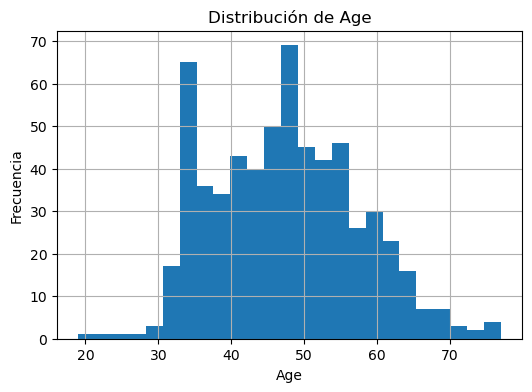

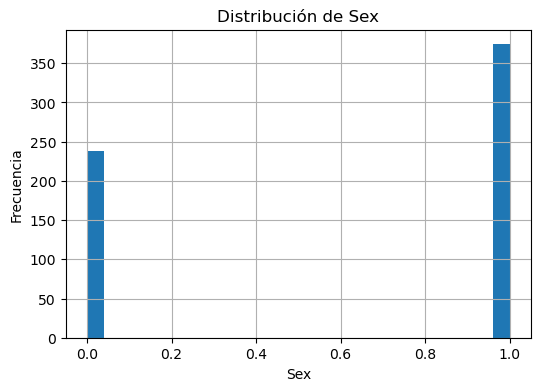

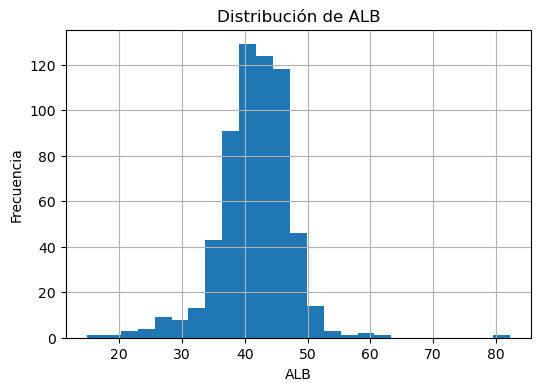

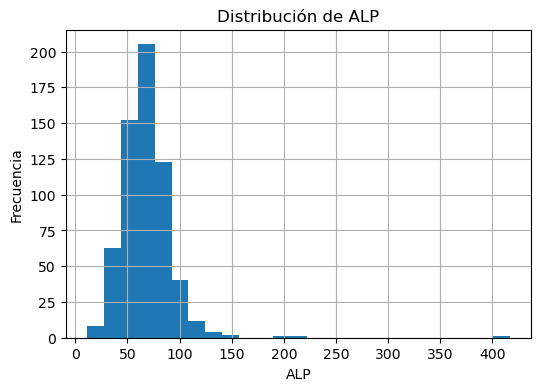

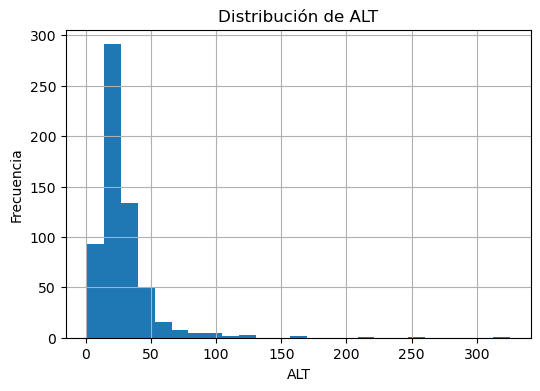

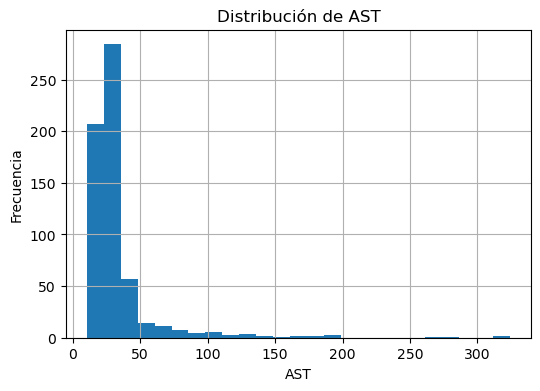

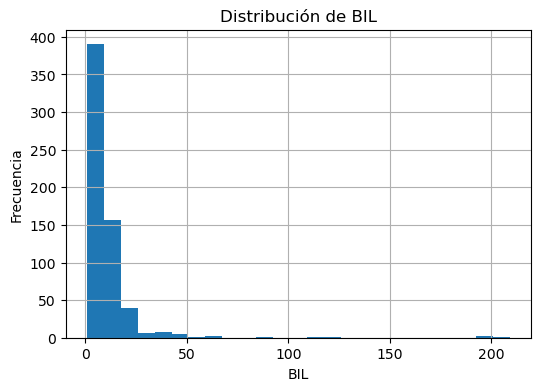

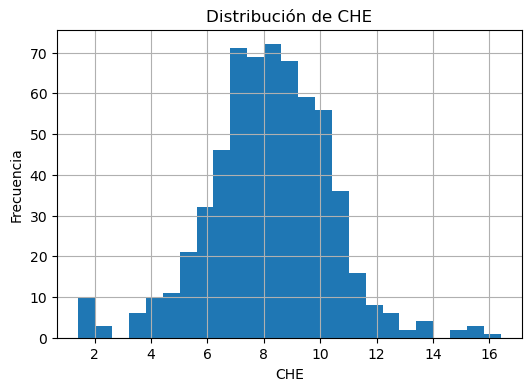

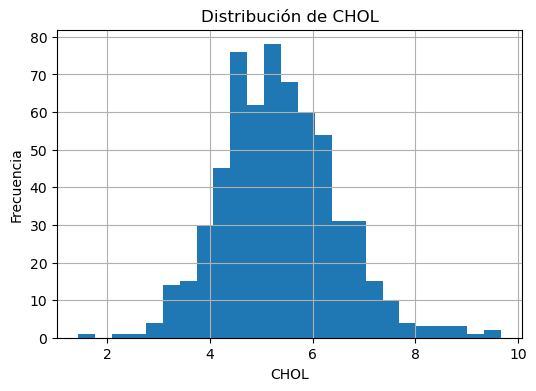

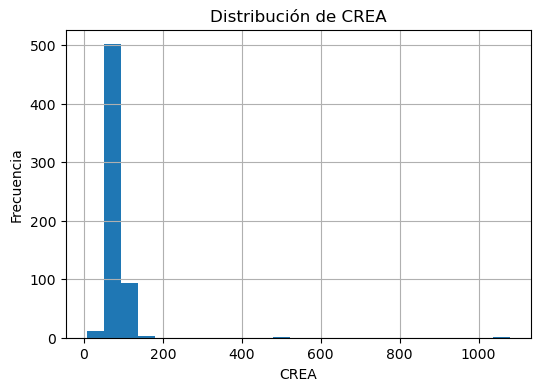

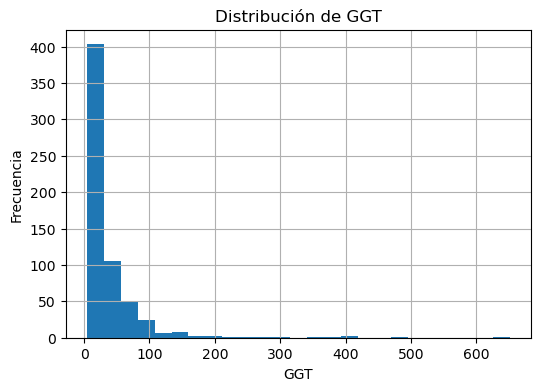

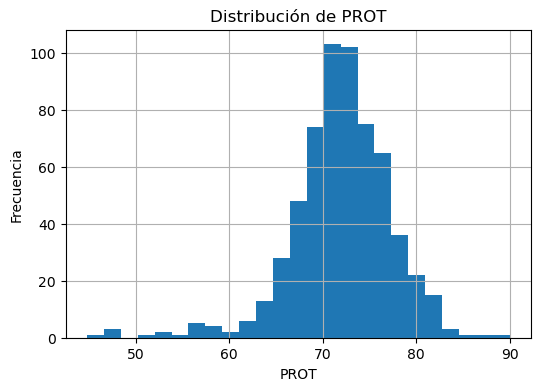

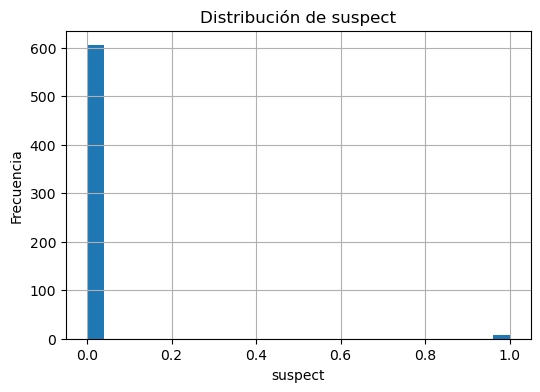

In [14]:
feature_cols = [col for col in df.columns if col != "target"]

for col in feature_cols:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=25)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

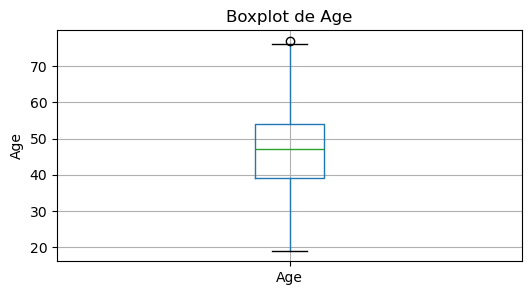

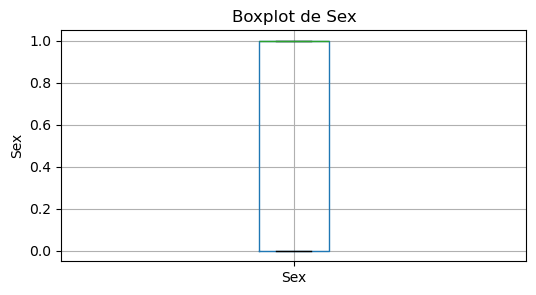

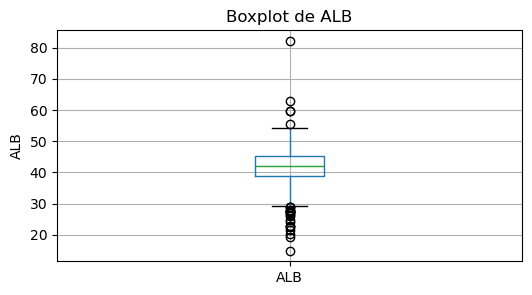

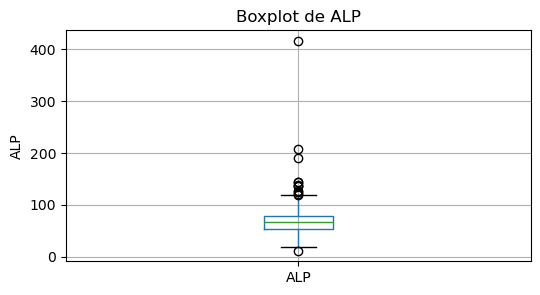

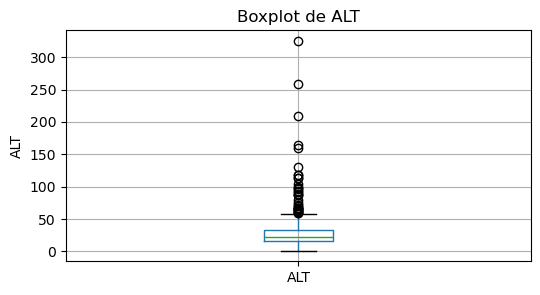

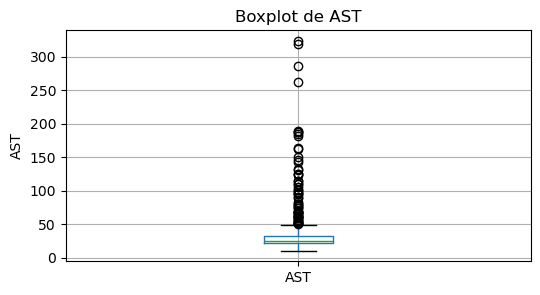

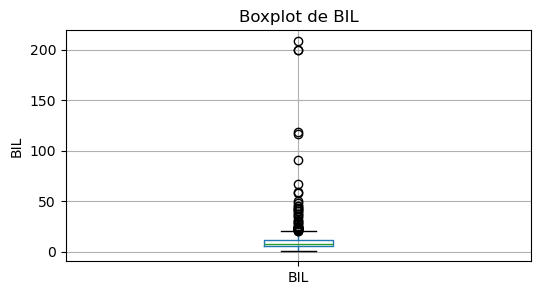

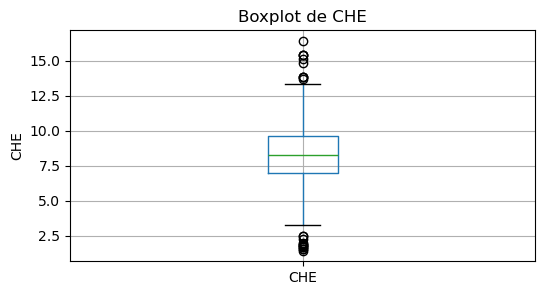

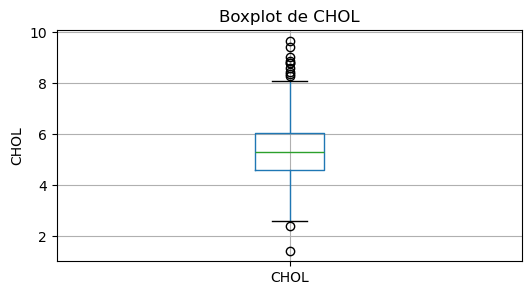

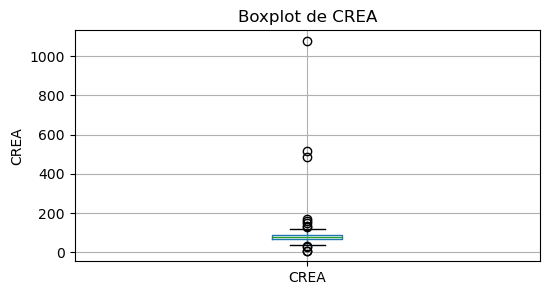

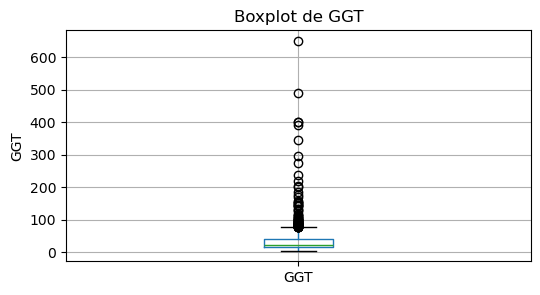

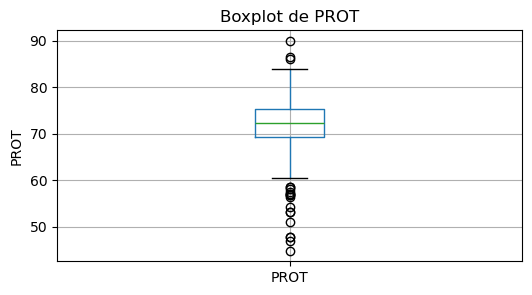

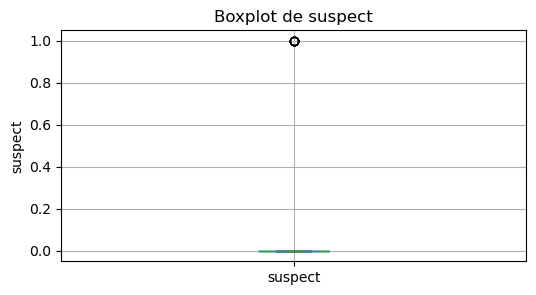

In [15]:
for col in feature_cols:
    plt.figure(figsize=(6, 3))
    df.boxplot(column=col)
    plt.title(f"Boxplot de {col}")
    plt.ylabel(col)
    plt.show()

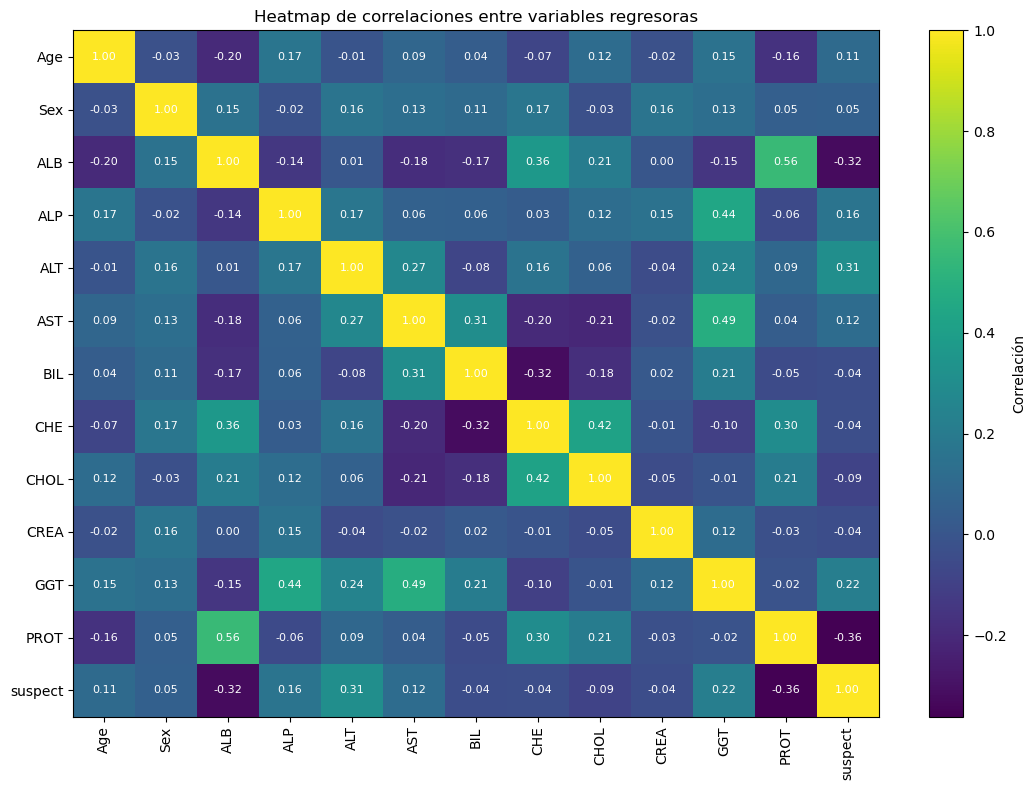

In [21]:
corr = df[feature_cols].corr()

plt.figure(figsize=(11,8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlación")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

# Agregar valores de correlación
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white",
            fontsize=8
        )

plt.title("Heatmap de correlaciones entre variables regresoras")
plt.tight_layout()
plt.show()

### Comentario del análisis descriptivo

Las variables clínicas presentan escalas muy distintas. Por ejemplo, `CREA`, `GGT`, `ALP`, `ALT` y `AST` pueden tener valores mucho más altos que variables como `CHOL` o `CHE`. Por eso la estandarización es necesaria antes de la regresión logística.

También se observan posibles outliers en variables bioquímicas, algo esperable en una base asociada a mediciones clínicas. No se eliminan automáticamente, porque pueden ser señales importantes para detectar enfermedad.

## 7. Separación de variables y estandarización

Se separan las variables regresoras (`X`) y la variable objetivo (`y`). Luego se estandariza con `StandardScaler`.

Finalmente, se divide la muestra en:

- 67% entrenamiento
- 33% test

In [22]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Distribución y_train:")
print(y_train.value_counts(normalize=True))
print("Distribución y_test:")
print(y_test.value_counts(normalize=True))

Tamaño X_train: (410, 13)
Tamaño X_test: (202, 13)
Distribución y_train:
target
0    0.870732
1    0.129268
Name: proportion, dtype: float64
Distribución y_test:
target
0    0.871287
1    0.128713
Name: proportion, dtype: float64


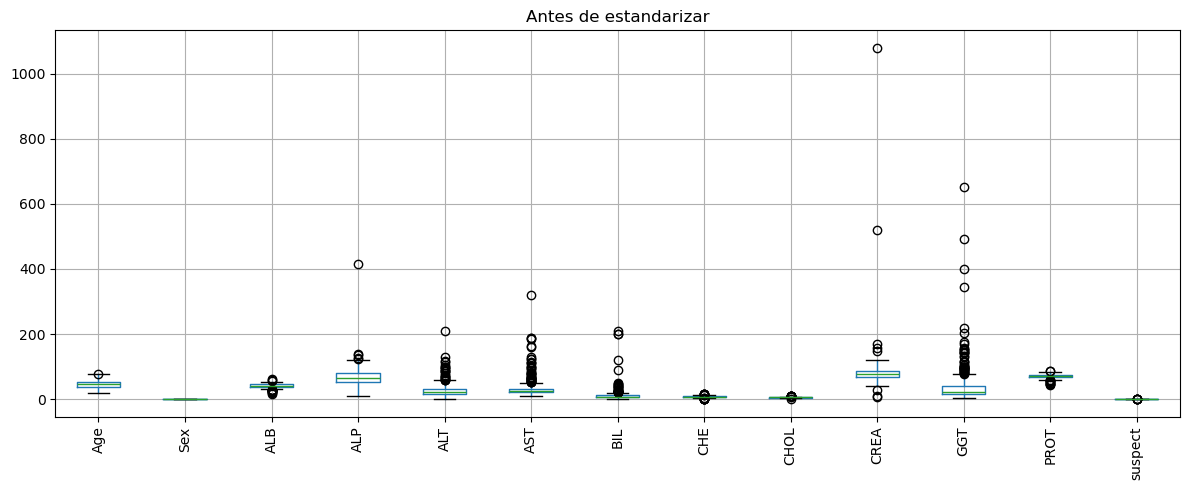

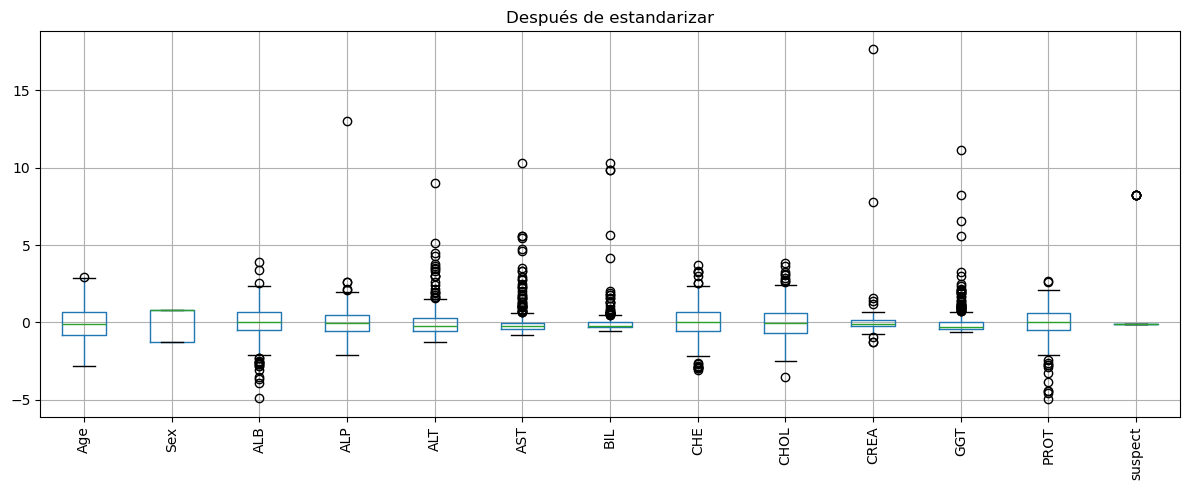

In [23]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

fig_data = [("Antes de estandarizar", X_train), ("Después de estandarizar", X_train_scaled)]

for title, data in fig_data:
    plt.figure(figsize=(12, 5))
    data.boxplot(rot=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 8. Modelo 1: Regresión logística con Elastic Net y validación cruzada

Se utiliza `LogisticRegressionCV` con:

- Validación cruzada 5-fold.
- Regularización Elastic Net.
- `Cs`: 200 valores lineales entre 0.01 y 5.0.
- `l1_ratio`: 200 valores lineales entre 0 y 1.
- Métrica de selección: `f1`, porque la clase positiva es minoritaria.

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Cs = np.linspace(0.01, 5.0, 200)
l1_ratios = np.linspace(0, 1, 200)

logit_elastic = LogisticRegressionCV(
    Cs=Cs,
    cv=cv,
    penalty="elasticnet",
    solver="saga",
    l1_ratios=l1_ratios,
    scoring="f1",
    max_iter=5000,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

logit_elastic.fit(X_train_scaled, y_train)

print("Mejor C:", logit_elastic.C_[0])
print("Mejor l1_ratio:", logit_elastic.l1_ratio_[0])

Mejor C: 0.060150753768844226
Mejor l1_ratio: 0.020100502512562814


In [25]:
y_pred_logit = logit_elastic.predict(X_test_scaled)

print(classification_report(y_test, y_pred_logit, digits=4))
print("Accuracy:", accuracy_score(y_test, y_pred_logit))
print("Precision:", precision_score(y_test, y_pred_logit))
print("Recall:", recall_score(y_test, y_pred_logit))
print("F1-score:", f1_score(y_test, y_pred_logit))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_logit))

              precision    recall  f1-score   support

           0     0.9777    0.9943    0.9859       176
           1     0.9565    0.8462    0.8980        26

    accuracy                         0.9752       202
   macro avg     0.9671    0.9202    0.9419       202
weighted avg     0.9749    0.9752    0.9746       202

Accuracy: 0.9752475247524752
Precision: 0.9565217391304348
Recall: 0.8461538461538461
F1-score: 0.8979591836734694
Matriz de confusión:
[[175   1]
 [  4  22]]


In [26]:
coeficientes = pd.DataFrame({
    "variable": X_train.columns,
    "coeficiente": logit_elastic.coef_[0],
})
coeficientes["importancia_abs"] = coeficientes["coeficiente"].abs()
coeficientes = coeficientes.sort_values("importancia_abs", ascending=False)
coeficientes.head(10)

,variable,coeficiente,importancia_abs
5,AST,1.097559,1.097559
10,GGT,0.901288,0.901288
3,ALP,-0.733007,0.733007
12,suspect,0.550794,0.550794
8,CHOL,-0.448837,0.448837
6,BIL,0.375715,0.375715
2,ALB,-0.352417,0.352417
11,PROT,0.322679,0.322679
9,CREA,0.301310,0.301310
4,ALT,-0.167856,0.167856


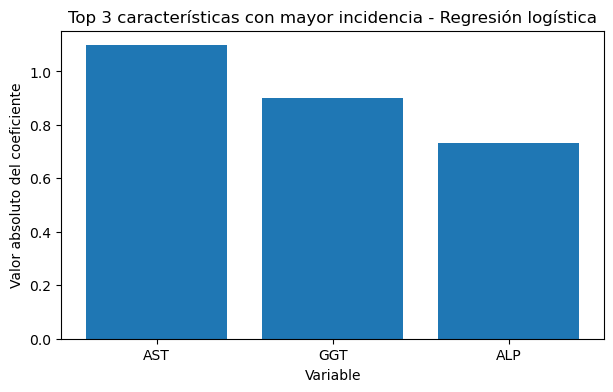

,variable,coeficiente,importancia_abs
5,AST,1.097559,1.097559
10,GGT,0.901288,0.901288
3,ALP,-0.733007,0.733007


In [27]:
top3_logit = coeficientes.head(3)

plt.figure(figsize=(7, 4))
plt.bar(top3_logit["variable"], top3_logit["importancia_abs"])
plt.title("Top 3 características con mayor incidencia - Regresión logística")
plt.xlabel("Variable")
plt.ylabel("Valor absoluto del coeficiente")
plt.show()

top3_logit

### Interpretación del modelo Elastic Net

Las variables con mayor valor absoluto del coeficiente son las que más influyen en la predicción. Un coeficiente positivo aumenta la probabilidad estimada de pertenecer a la clase `1`, mientras que un coeficiente negativo la reduce.

Como las variables fueron estandarizadas, los coeficientes son comparables entre sí.

## 9. Modelo 2: Extreme Gradient Boosting con grilla de hiperparámetros

Se implementa un modelo XGBoost y se buscan hiperparámetros para regularización L1 y L2:

- `reg_lambda`: 10 valores lineales entre 0.0 y 2.0.
- `reg_alpha`: 10 valores lineales entre 0.0 y 1.0.
- `learning_rate`: 20 valores lineales entre 0.1 y 10.

Se usa `scale_pos_weight` para compensar el desbalance de clases.

In [28]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=60,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=1,
    scale_pos_weight=scale_pos_weight
)

param_grid_xgb = {
    "reg_lambda": np.linspace(0.0, 2.0, 10),
    "reg_alpha": np.linspace(0.0, 1.0, 10),
    "learning_rate": np.linspace(0.1, 10.0, 20)
}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("Mejores hiperparámetros XGBoost:")
print(grid_xgb.best_params_)
print("Mejor F1 promedio en CV:", grid_xgb.best_score_)

Fitting 5 folds for each of 2000 candidates, totalling 10000 fits
Mejores hiperparámetros XGBoost:
{'learning_rate': np.float64(1.6631578947368424), 'reg_alpha': np.float64(0.1111111111111111), 'reg_lambda': np.float64(2.0)}
Mejor F1 promedio en CV: 0.9052914895935491


In [29]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb, digits=4))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0     0.9887    0.9943    0.9915       176
           1     0.9600    0.9231    0.9412        26

    accuracy                         0.9851       202
   macro avg     0.9744    0.9587    0.9663       202
weighted avg     0.9850    0.9851    0.9850       202

Accuracy: 0.9851485148514851
Precision: 0.96
Recall: 0.9230769230769231
F1-score: 0.9411764705882353
Matriz de confusión:
[[175   1]
 [  2  24]]


In [30]:
importancias_xgb = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": best_xgb.feature_importances_
}).sort_values("importancia", ascending=False)

importancias_xgb.head(10)

,variable,importancia
5,AST,0.566849
4,ALT,0.147329
10,GGT,0.091174
8,CHOL,0.074424
3,ALP,0.036362
11,PROT,0.023563
2,ALB,0.020428
6,BIL,0.018435
7,CHE,0.017670
0,Age,0.002640


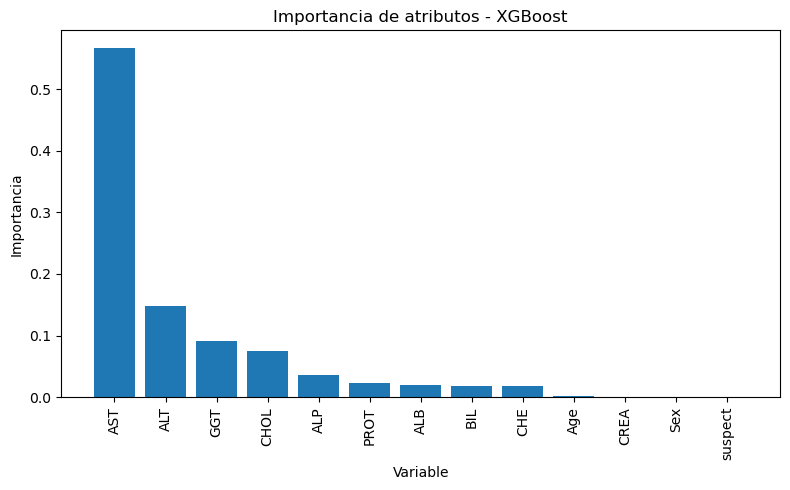

In [31]:
plt.figure(figsize=(8, 5))
plt.bar(importancias_xgb["variable"], importancias_xgb["importancia"])
plt.title("Importancia de atributos - XGBoost")
plt.xlabel("Variable")
plt.ylabel("Importancia")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 10. Comparación de modelos

Se comparan ambos modelos usando métricas en el conjunto de test:

- Accuracy
- Precision
- Recall
- F1-score

In [32]:
resultados = pd.DataFrame({
    "modelo": ["Regresión logística Elastic Net", "XGBoost"],
    "accuracy": [
        accuracy_score(y_test, y_pred_logit),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "precision": [
        precision_score(y_test, y_pred_logit),
        precision_score(y_test, y_pred_xgb)
    ],
    "recall": [
        recall_score(y_test, y_pred_logit),
        recall_score(y_test, y_pred_xgb)
    ],
    "f1_score": [
        f1_score(y_test, y_pred_logit),
        f1_score(y_test, y_pred_xgb)
    ]
})

resultados

,modelo,accuracy,precision,recall,f1_score
0,Regresión logística Elastic Net,0.975248,0.956522,0.846154,0.897959
1,XGBoost,0.985149,0.960000,0.923077,0.941176


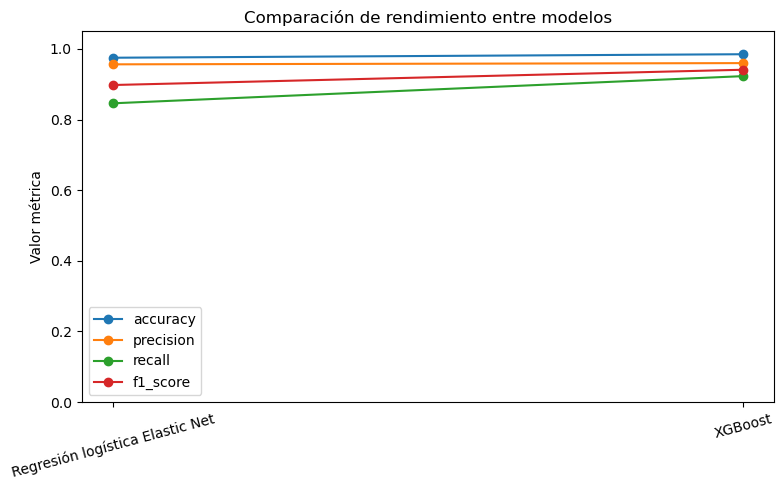

In [33]:
plt.figure(figsize=(8, 5))
for metric in ["accuracy", "precision", "recall", "f1_score"]:
    plt.plot(resultados["modelo"], resultados[metric], marker="o", label=metric)

plt.title("Comparación de rendimiento entre modelos")
plt.ylabel("Valor métrica")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

### Conclusión

Ambos modelos permiten clasificar adecuadamente la variable objetivo. La regresión logística con Elastic Net tiene la ventaja de ser más interpretable, porque permite revisar directamente los coeficientes de cada variable.

XGBoost, por su parte, puede capturar relaciones no lineales y suele mejorar el rendimiento cuando existen interacciones entre variables. La decisión final debe basarse principalmente en el `f1-score` y el `recall` de la clase positiva, porque el objetivo práctico es detectar posibles muestras asociadas a enfermedad, no solo tener un accuracy bonito para la foto.

Si XGBoost obtiene mejor `recall` o `f1-score`, sería el modelo recomendado para priorizar detección. Si la diferencia es pequeña, Elastic Net puede ser preferible por su interpretación más clara.